# Evaluasi Model Klasifikasi Kematangan Tomat
Dataset: matang, mentah, setengah_matang | Model: Random Forest

In [2]:
import os
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, 
recall_score, f1_score, classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Load Dataset

In [3]:
import os
import cv2
import numpy as np

# Jika direktori saat ini adalah notebooks, kembali ke direktori utama
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

CLASS_NAMES = ['matang', 'mentah', 'setengah_matang']
IMG_SIZE = (256, 256)
BINS = (8, 8, 8)

def extract_histogram(image):
    # PREPROCESSING 1: Gaussian Blur untuk menghilangkan noise/bintik pada gambar kamera
    image_blur = cv2.GaussianBlur(image, (5, 5), 0)
    
    # PREPROCESSING 2: Konversi ruang warna BGR menjadi HSV
    image_hsv = cv2.cvtColor(image_blur, cv2.COLOR_BGR2HSV)
    
    # PREPROCESSING 3: Pembuatan Mask (Filter Background)
    # Background (seperti dinding, meja, bayangan hitam) biasanya tidak memiliki warna (saturasi rendah)
    # Kita buat penutup (mask) untuk hanya mengambil piksel yang cerah dan berwarna (Tomat)
    # H: 0-180, S: 30-255, V: 30-255
    lower_bound = np.array([0, 30, 30])
    upper_bound = np.array([180, 255, 255])
    mask = cv2.inRange(image_hsv, lower_bound, upper_bound)
    
    features = []
    for i in range(3):
        # PREPROCESSING 4: Histogram dengan Masking (Hanya piksel "Tomat" yang dihitung)
        hist = cv2.calcHist([image_hsv], [i], mask, [BINS[i]], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        features.append(hist)
        
    return np.concatenate(features)

X, y = [], []
for label, cls in enumerate(CLASS_NAMES):
    folder_path = os.path.join('dataset', cls)
    if not os.path.exists(folder_path):
        print(f"Folder '{folder_path}' tidak ditemukan. Pastikan path sudah benar.")
        continue

    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"{cls}: {len(files)} gambar ditemukan.")

    for fname in files:
        img_path = os.path.join(folder_path, fname)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Gagal membaca gambar: {img_path}")
            continue

        # PREPROCESSING 5: Resize ukuran agar standar    
        img = cv2.resize(img, IMG_SIZE)
        
        # Ekstrak fitur
        X.append(extract_histogram(img))
        y.append(label)

X = np.array(X)
y = np.array(y)
print(f"Total: {len(y)} gambar siap ditraining!")


matang: 341 gambar ditemukan.
mentah: 232 gambar ditemukan.
setengah_matang: 402 gambar ditemukan.
Total: 975 gambar siap ditraining!


# 2.Visualisasi Pra-pemrosesan: RGB vs HSV

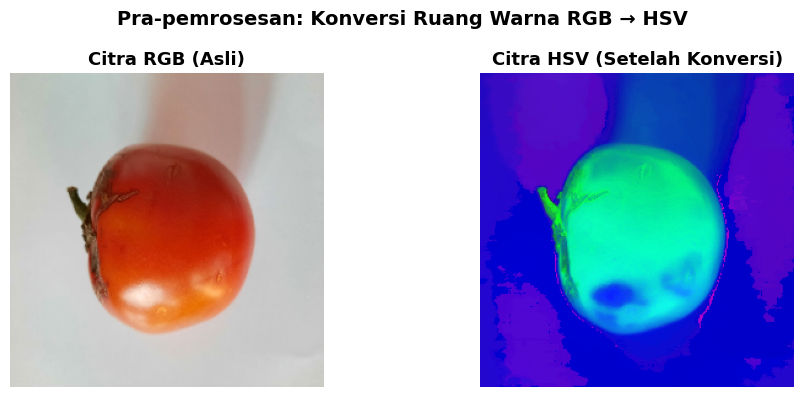

Gambar sample: dataset\matang\1 (1).jpg


In [5]:
# ============================================================
# Visualisasi Pra-pemrosesan: RGB vs HSV
# ============================================================

sample_path = None
for cls in CLASS_NAMES:
    folder = os.path.join('dataset', cls)
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if files:
        sample_path = os.path.join(folder, files[0])
        break

img_bgr = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_resized_rgb = cv2.resize(img_rgb, IMG_SIZE)
img_resized_hsv = cv2.resize(img_hsv, IMG_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_resized_rgb)
axes[0].set_title('Citra RGB (Asli)', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_resized_hsv)
axes[1].set_title('Citra HSV (Setelah Konversi)', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Pra-pemrosesan: Konversi Ruang Warna RGB → HSV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/preprocessing_rgb_vs_hsv.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Gambar sample: {sample_path}")

DATA DUPLIKAT

In [6]:
import os
import hashlib

def get_file_hash(filepath):
    # Menggunakan MD5 untuk mendapatkan "sidik jari" (hash) unik dari setiap file
    hasher = hashlib.md5()
    with open(filepath, 'rb') as f:
        buf = f.read()
        hasher.update(buf)
    return hasher.hexdigest()

def find_and_delete_duplicates(dataset_dir):
    seen_hashes = {}
    duplicates = []
    
    # Mencari ke dalam folder matang, mentah, dan setengah_matang
    for root, _, files in os.walk(dataset_dir):
        for filename in files:
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                filepath = os.path.join(root, filename)
                file_hash = get_file_hash(filepath)
                
                if file_hash in seen_hashes:
                    duplicates.append(filepath)
                    print(f"Hapus duplikat: {filepath}")
                else:
                    seen_hashes[file_hash] = filepath
                    
    # Melakukan penghapusan file
    for dup in duplicates:
        os.remove(dup)
        
    print(f"\nProses selesai! Total gambar duplikat yang dihapus: {len(duplicates)}")

if __name__ == "__main__":
    dataset_path = 'dataset'
    if not os.path.exists(dataset_path):
        dataset_path = os.path.join('..', 'dataset') # jika dijalankan di dalam folder notebooks
        
    find_and_delete_duplicates(dataset_path)



Proses selesai! Total gambar duplikat yang dihapus: 0


## 3. Split Dataset into Training and Testing Sets

In [8]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set distribution: {np.bincount(y_train)}")
print(f"Testing set distribution: {np.bincount(y_test)}")

# Batasi kedalaman pohon (max_depth) dan jumlah minimal sampel (min_samples_split)
model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=4,                # Membatasi logika percabangan maksimal 4 level
    min_samples_split=20,       # Butuh 20 gambar untuk menyimpulkan sebuah aturan
    min_samples_leaf=10,        # Setiap daun (ujung pohon) minimal punya 10 sampel
    random_state=42
)

# Training model
print("Training model...")
model.fit(X_train, y_train)
print("Model training completed!")

# Memeriksa skor
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)
print(f"Training Accuracy: {accuracy_score(y_train, train_predictions) * 100:.2f}%")
print(f"Testing Accuracy: {accuracy_score(y_test, test_predictions) * 100:.2f}%")

Training set size: 780 samples
Testing set size: 195 samples
Training set distribution: [273 185 322]
Testing set distribution: [68 47 80]
Training model...
Model training completed!
Training Accuracy: 91.54%
Testing Accuracy: 94.36%


## 4. Metrik Evaluasi

In [9]:
# Menghasilkan tebakan (prediksi) ke seluruh data X
y_pred = model.predict(X)

# Menghitung Metrik Evaluasi Keseluruhan
acc  = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred, average='weighted')
rec  = recall_score(y, y_pred, average='weighted')
f1   = f1_score(y, y_pred, average='weighted')

print(f"Akurasi   : {acc*100:.2f}%")
print(f"Precision : {prec*100:.2f}%")
print(f"Recall    : {rec*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")


Akurasi   : 92.10%
Precision : 92.78%
Recall    : 92.10%
F1-Score  : 92.14%


## 5. Confusion Matrix

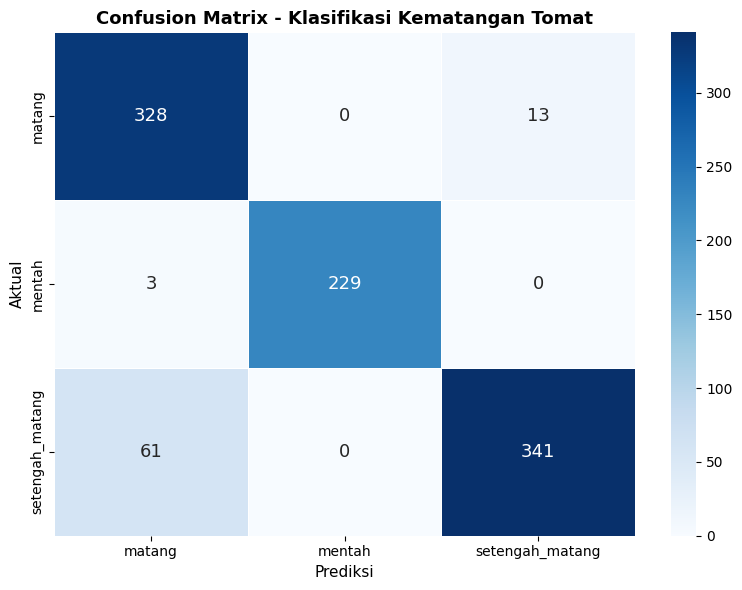

In [10]:
cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, annot_kws={"size": 13})
ax.set_title('Confusion Matrix - Klasifikasi Kematangan Tomat', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Aktual', fontsize=11)
ax.set_xlabel('Prediksi', fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix_eval.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Classification Report

In [11]:
print(classification_report(y, y_pred, target_names=CLASS_NAMES))

                 precision    recall  f1-score   support

         matang       0.84      0.96      0.89       341
         mentah       1.00      0.99      0.99       232
setengah_matang       0.96      0.85      0.90       402

       accuracy                           0.92       975
      macro avg       0.93      0.93      0.93       975
   weighted avg       0.93      0.92      0.92       975



## 8. Ringkasan Akhir

In [12]:
print(f"{'Kelas':<22} {'Benar':>6} {'Total':>6} {'Akurasi':>10}")
print("-" * 46)
for i, cls in enumerate(CLASS_NAMES):
    total = int(np.sum(y == i))
    benar = int(np.sum((y == i) & (y_pred == i)))
    print(f"{cls:<22} {benar:>6} {total:>6} {benar/total*100:>9.1f}%")
print(f"\nAkurasi keseluruhan : {acc*100:.2f}%")
print(f"Precision weighted  : {prec*100:.2f}%")
print(f"Recall weighted     : {rec*100:.2f}%")
print(f"F1-Score weighted   : {f1*100:.2f}%")

Kelas                   Benar  Total    Akurasi
----------------------------------------------
matang                    328    341      96.2%
mentah                    229    232      98.7%
setengah_matang           341    402      84.8%

Akurasi keseluruhan : 92.10%
Precision weighted  : 92.78%
Recall weighted     : 92.10%
F1-Score weighted   : 92.14%


## 9. Import model.pkl 

In [13]:
import joblib
import os

# Menentukan folder penyimpanan (berada di c:\code\data_tomat\model)
model_dir = 'model'
if os.getcwd().endswith('notebooks'):
    model_dir = os.path.join('..', 'model')

# Membuat folder "model" jika belum ada
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Path lengkap untuk menyimpan file
model_path = os.path.join(model_dir, 'modeltomat.pkl')

# Menyimpan model
joblib.dump(model, model_path)
print(f"Bagus! Model berhasil disimpan secara permanen di: {os.path.abspath(model_path)}")


Bagus! Model berhasil disimpan secara permanen di: c:\data_tomat\model\modeltomat.pkl
